<a href="https://colab.research.google.com/github/ggyupi/PCVK_Ganjil_2025/blob/main/MORFOLOGI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


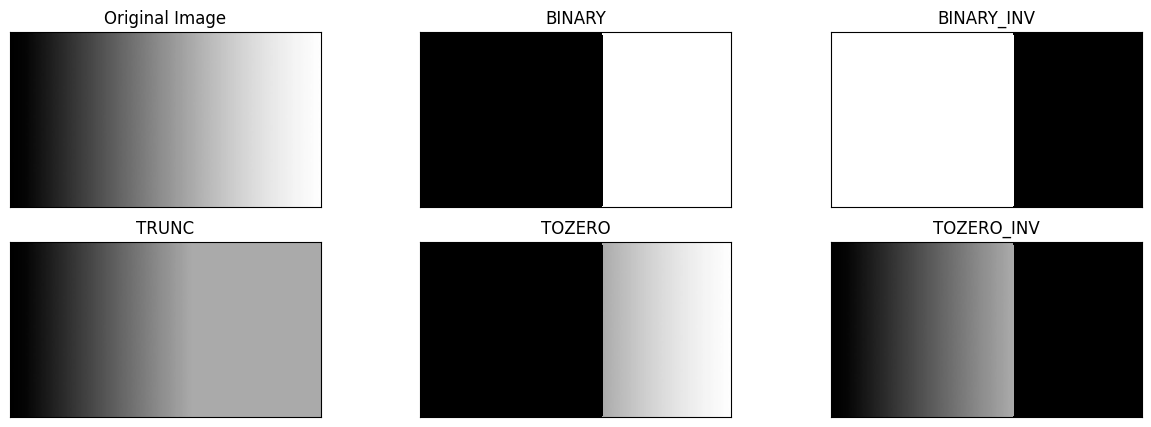

In [ ]:
import cv2 as cv
from google.colab.patches import cv2_imshow
import numpy as np
import matplotlib.pyplot as plt

filename = ('/content/drive/MyDrive/PCVK/images/gradient.jpg')
img = cv.imread(filename)
thresh = 170      #nilai Threshold yang ditentukan

#1. thresh1 jika pixel di img>127, maka thresh1 bernilai 1(putih) selain itu bernilai 0(hitam)
ret,thresh1 = cv.threshold(img,thresh,255,cv.THRESH_BINARY)
#2. thresh2 adalah binary threshold inverse
ret,thresh2 = cv.threshold(img,thresh,255,cv.THRESH_BINARY_INV)
#3. Threshold Truncate
ret,thresh3 = cv.threshold(img,thresh,255,cv.THRESH_TRUNC)
#4. Threshold Tozero
ret,thresh4 = cv.threshold(img,thresh,255,cv.THRESH_TOZERO)
#5. Threshold Tozero Inverse
ret,thresh5 = cv.threshold(img,thresh,255,cv.THRESH_TOZERO_INV)

titles = ['Original Image','BINARY','BINARY_INV','TRUNC', 'TOZERO', 'TOZERO_INV']
images = [img, thresh1, thresh2, thresh3, thresh4, thresh5]

plt.figure(figsize = (15,5))
for i in range(len(images)):
  plt.subplot(2,3,i+1),plt.imshow(images[i],'gray', interpolation='nearest')
  plt.title(titles[i])
  plt.xticks([]),plt.yticks([])
plt.show()

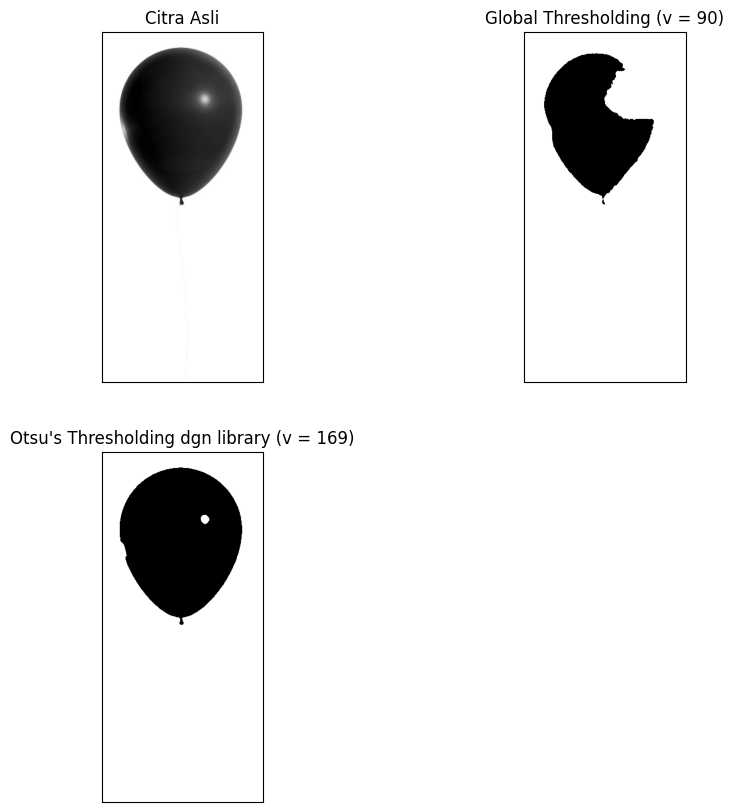

In [ ]:
# Membaca gambar grayscale
path ='/content/drive/MyDrive/PCVK/images/balloon.jpg'

# Preprocessing: median blur untuk mengurangi noise
citra = cv.medianBlur(cv.imread(path), 5)

# Ubah ke grayscale
gray = cv.cvtColor(citra, cv.COLOR_BGR2GRAY)
# Jika ingin, bisa aktifkan blur tambahan:
# gray = cv.medianBlur(gray,5)

# Global threshold manual (v = 90)
thresh = 90
ret, th1 = cv.threshold(gray, thresh, 255, cv.THRESH_BINARY)

# Otsu threshold otomatis (tanpa menentukan T manual)
ret2, th2 = cv.threshold(gray, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)

# Tampilkan hasil
x = "Otsu's Thresholding dgn library (v = " + str(int(ret2)) + ")"
titles = ['Citra Asli', 'Global Thresholding (v = 90)', x]
citra2 = [gray, th1, th2]

plt.figure(figsize=(10,10))
for i in range(len(citra2)):
    plt.subplot(2,2,i+1)
    plt.imshow(citra2[i], 'gray')
    plt.title(titles[i])
    plt.xticks([]), plt.yticks([])
plt.show()

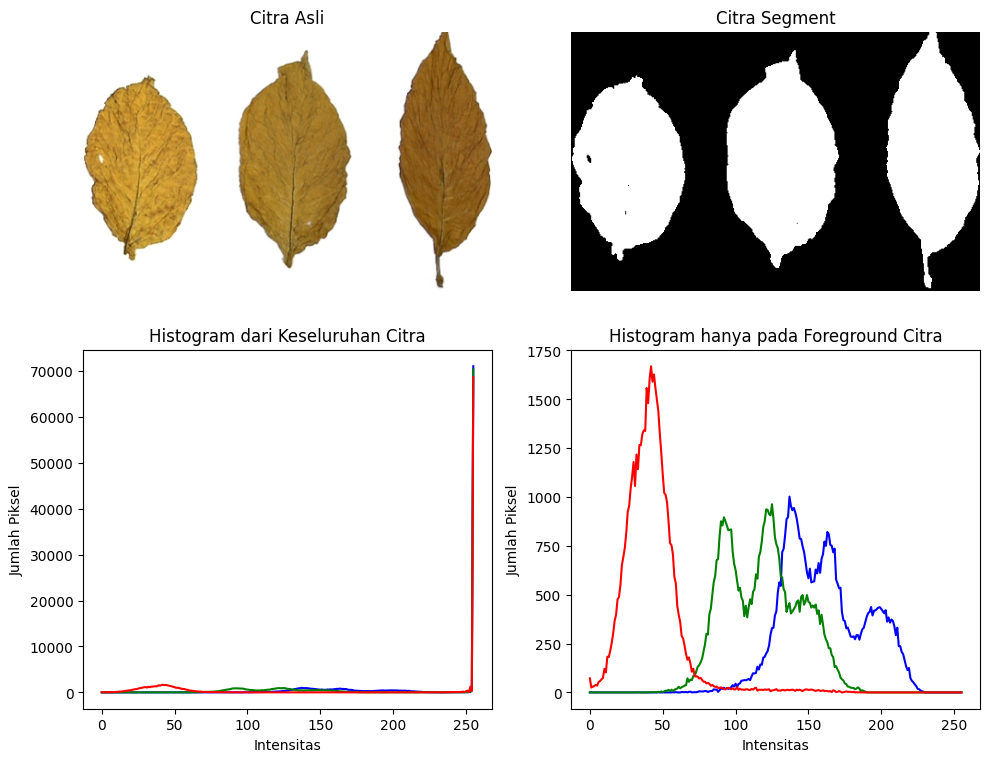

In [ ]:
# Baca gambar
filename = ('/content/drive/MyDrive/PCVK/images/tobacco.png')
img = cv.imread(filename)
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
gray = cv.cvtColor(img, cv.COLOR_RGB2GRAY)

# Buat mask foreground dengan threshold Otsu
_, mask = cv.threshold(gray, 0, 255, cv.THRESH_BINARY_INV + cv.THRESH_OTSU)

# Segmentasikan citra menggunakan mask
segment = cv.bitwise_and(img, img, mask=mask)

# Warna untuk histogram (B, G, R)
color = ('b', 'g', 'r')

plt.figure(figsize=(10, 8))

# Citra asli
plt.subplot(2, 2, 1)
plt.imshow(img)
plt.title("Citra Asli")
plt.axis('off')

# Mask hasil segmentasi
plt.subplot(2, 2, 2)
plt.imshow(mask, cmap='gray')
plt.title("Citra Segment")
plt.axis('off')

# Histogram keseluruhan citra
plt.subplot(2, 2, 3)
for i, col in enumerate(color):
    hist = cv.calcHist([img], [i], None, [256], [0, 256])
    plt.plot(hist, color=col)
plt.title("Histogram dari Keseluruhan Citra")
plt.xlabel("Intensitas")
plt.ylabel("Jumlah Piksel")

# Histogram hanya pada foreground (area putih di mask)
plt.subplot(2, 2, 4)
for i, col in enumerate(color):
    hist_fg = cv.calcHist([img], [i], mask, [256], [0, 256])
    plt.plot(hist_fg, color=col)
plt.title("Histogram hanya pada Foreground Citra")
plt.xlabel("Intensitas")
plt.ylabel("Jumlah Piksel")

plt.tight_layout()
plt.show()

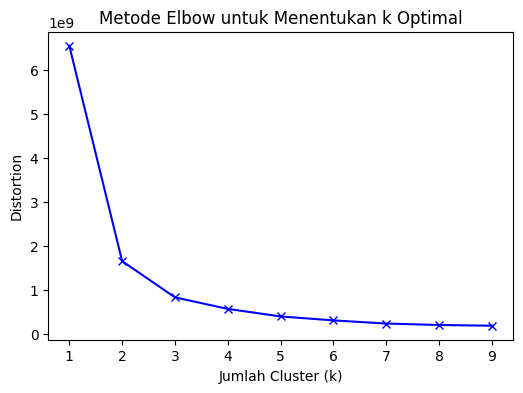

In [ ]:
# Baca gambar
filename = '/content/drive/MyDrive/PCVK/images/peppers.jpg'
img = cv.imread(filename)
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Ubah menjadi array 2D dan ubah tipe data ke float32
pixel_values = img.reshape((-1, 3))
pixel_values = np.float32(pixel_values)

# Kriteria konvergensi untuk K-Means
criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 100, 0.2)

# Hitung nilai distortion untuk tiap k
distortions = []
K = range(1, 10)
for k in K:
    compactness, labels, centers = cv.kmeans(
        pixel_values, k, None, criteria, 10, cv.KMEANS_RANDOM_CENTERS
    )
    distortions.append(compactness)

# Plot metode Elbow
plt.figure(figsize=(6, 4))
plt.plot(K, distortions, 'bx-')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Distortion')
plt.title('Metode Elbow untuk Menentukan k Optimal')
plt.show()


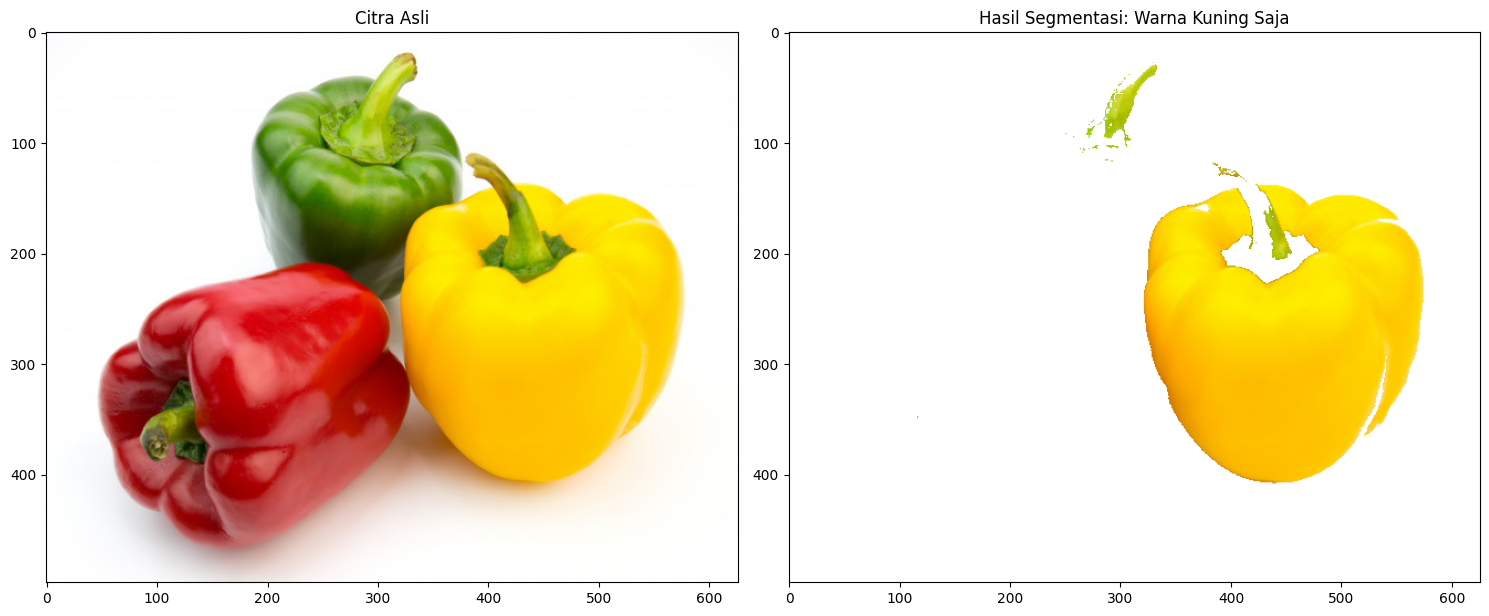

In [ ]:
# Baca dan ubah ke RGB
filename = '/content/drive/MyDrive/PCVK/images/peppers.jpg'
img = cv.imread(filename)
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Ubah menjadi array 2D (setiap pixel jadi 1 baris dengan 3 nilai RGB)
pixel_values = img.reshape((-1, 3))
pixel_values = np.float32(pixel_values)

# Kriteria K-Means (berhenti jika konvergen atau iterasi >= 100)
criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 100, 0.2)

# Jumlah cluster (gunakan 5 biar warna lebih terpisah)
k = 5
_, labels, centers = cv.kmeans(
    pixel_values, k, None, criteria, 10, cv.KMEANS_RANDOM_CENTERS
)

# Konversi ke integer dan reshape
centers = np.uint8(centers)
labels = labels.flatten()

# Tentukan cluster dengan warna kuning dominan (R dan G tinggi, B rendah)
yellow_cluster = None
for i, (r, g, b) in enumerate(centers):
    if r > 150 and g > 150 and b < 120:
        yellow_cluster = i
        break

# Buat mask hanya untuk cluster kuning
mask = (labels == yellow_cluster) if yellow_cluster is not None else np.zeros_like(labels, dtype=bool)
mask = mask.reshape(img.shape[:2])

# Buat citra hasil isolasi: area lain diubah jadi putih
isolated = np.ones_like(img) * 255
isolated[mask] = img[mask]

# Visualisasi hasil
plt.figure(figsize=(15, 10))
plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title('Citra Asli')

plt.subplot(1, 2, 2)
plt.imshow(isolated)
plt.title('Hasil Segmentasi: Warna Kuning Saja')

plt.tight_layout()
plt.show()

Kendalanya, warna kuning tidak tersegmentasi sempurna dan sebagian hijau ikut muncul karena K-Means mengelompokkan warna berdasarkan kedekatan nilai RGB, bukan persepsi warna. Variasi pencahayaan juga membuat beberapa piksel kuning masuk ke cluster lain.

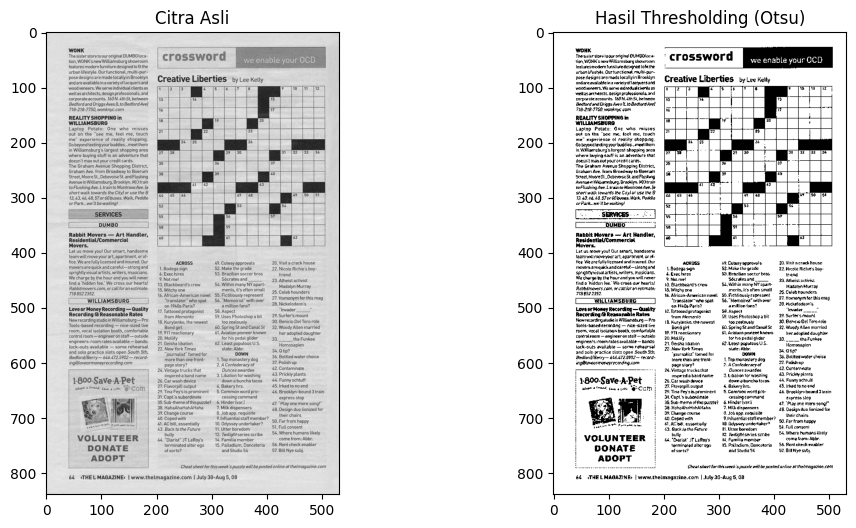

In [ ]:
# Baca gambar dan ubah ke grayscale
filename = '/content/drive/MyDrive/PCVK/images/crossword.jpg'
img = cv.imread(filename, cv.IMREAD_GRAYSCALE)

# Lakukan thresholding dengan metode Otsu
_, thresh = cv.threshold(img, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)

# Tampilkan hasil
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title('Citra Asli')

plt.subplot(1,2,2)
plt.imshow(thresh, cmap='gray')
plt.title('Hasil Thresholding (Otsu)')

plt.show()

Metode Otsu secara otomatis menghitung nilai ambang terbaik untuk membedakan area terang dan gelap tanpa harus menentukan threshold secara manual.